In [1]:
import numpy as np                              # numeric operations
import pandas as pd                             # data loading and manipulation
import matplotlib.pyplot as plt                 # plotting
import seaborn as sns                           # nicer plot styling

from sklearn.preprocessing import StandardScaler  # scales features to mean 0 / std 1
from sklearn.decomposition import PCA              # dimensionality reduction


In [2]:
data = pd.read_csv("Mall_Customers.csv")  # load the mall customers dataset

In [3]:
print(data.head())  # preview the first 5 rows
print(data.shape)  # (rows, columns) of the dataset


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


In [4]:
data.info()  # column dtypes and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
data.describe()  # summary stats (mean, std, min, max) for numeric columns

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
data.columns = data.columns.str.strip()  # remove any stray whitespace from column names

In [7]:
print(data["Gender"].value_counts())  # count of Male vs Female customers

Gender
Female    112
Male       88
Name: count, dtype: int64


In [8]:
data['Gender_code'] = data['Gender'].map({"Female": 0, "Male": 1})  # encode Gender as a numeric 0/1 column

In [9]:
data['Gender_code']  # preview the encoded column

0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    1
198    1
199    1
Name: Gender_code, Length: 200, dtype: int64

In [10]:
print(data["Gender_code"].value_counts())  # confirm the encoding counts match the Gender counts

Gender_code
0    112
1     88
Name: count, dtype: int64


In [11]:
features = [                            # columns to use for clustering
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)',
    'Gender_code'
]
X = data[features]                      # feature matrix for PCA/clustering


In [12]:
scaler = StandardScaler()                          # scaler to standardize features before PCA
x_scaled = scaler.fit_transform(X)                  # scale features to mean 0, std 1
pca = PCA(n_components=2, random_state=0)           # reduce to 2 principal components for visualization
x_pca = pca.fit_transform(x_scaled)                 # fit PCA and transform the scaled features
print("PCA Shape", x_pca.shape)                     # confirm the reduced shape (rows, 2)
print("Explained variance ratio:", pca.explained_variance_ratio_)  # how much info each component keeps


PCA Shape (200, 2)
Explained variance ratio: [0.33690046 0.26230645]


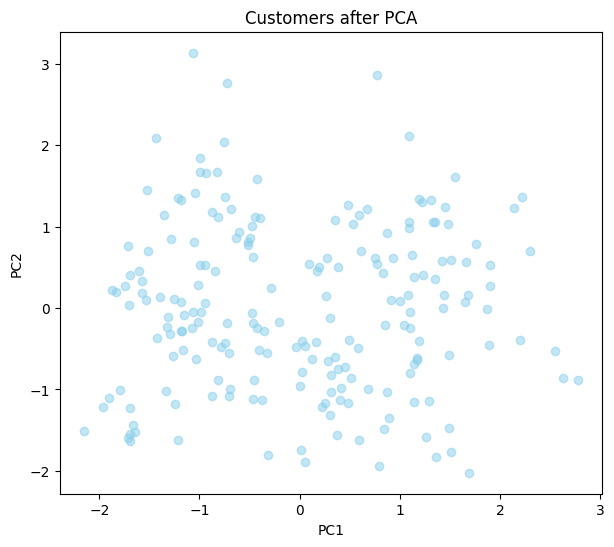

In [13]:
plt.figure(figsize=(7, 6))                      # set plot size
plt.scatter(x_pca[:, 0], x_pca[:, 1], c='skyblue', alpha=0.5)  # scatter the 2 principal components
plt.xlabel('PC1')                               # x-axis label
plt.ylabel('PC2')                                # y-axis label
plt.title('Customers after PCA')                # chart title
plt.show()                                      # display the PCA scatter plot
